In [1]:
!pip install grad-cam medmnist
!pip install captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 22.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 10.4 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=2e340272de1d475032bced8f88ee02104a3c06a61299a9e408f8b955055e5c2e
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following d

In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import PathMNIST
import matplotlib.pyplot as plt
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# 1. Pipeline de Dados (Apenas Validação para a Explicabilidade)
transformacao = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_dataset = PathMNIST(split="val", size=224, download=True, transform=transformacao)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# 2. Reconstruindo a Arquitetura (O Esqueleto)
class CNNAutoral(nn.Module):
    def __init__(self, num_classes=9):
        super(CNNAutoral, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

# 3. Injetando os Pesos (O Cérebro) e congelando a rede
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo = CNNAutoral().to(device)


pesos_path = "/kaggle/input/datasets/dheriisousa/pesos-rede-autoral/pesos_cnn_autoral.pth"

modelo.load_state_dict(torch.load(pesos_path, map_location=device))
modelo.eval() # Impede que o modelo tente aprender algo novo

print("✅ Infraestrutura de Explicabilidade Pronta!")

100%|██████████| 12.6G/12.6G [23:43<00:00, 8.88MB/s]


✅ Infraestrutura de Explicabilidade Pronta!


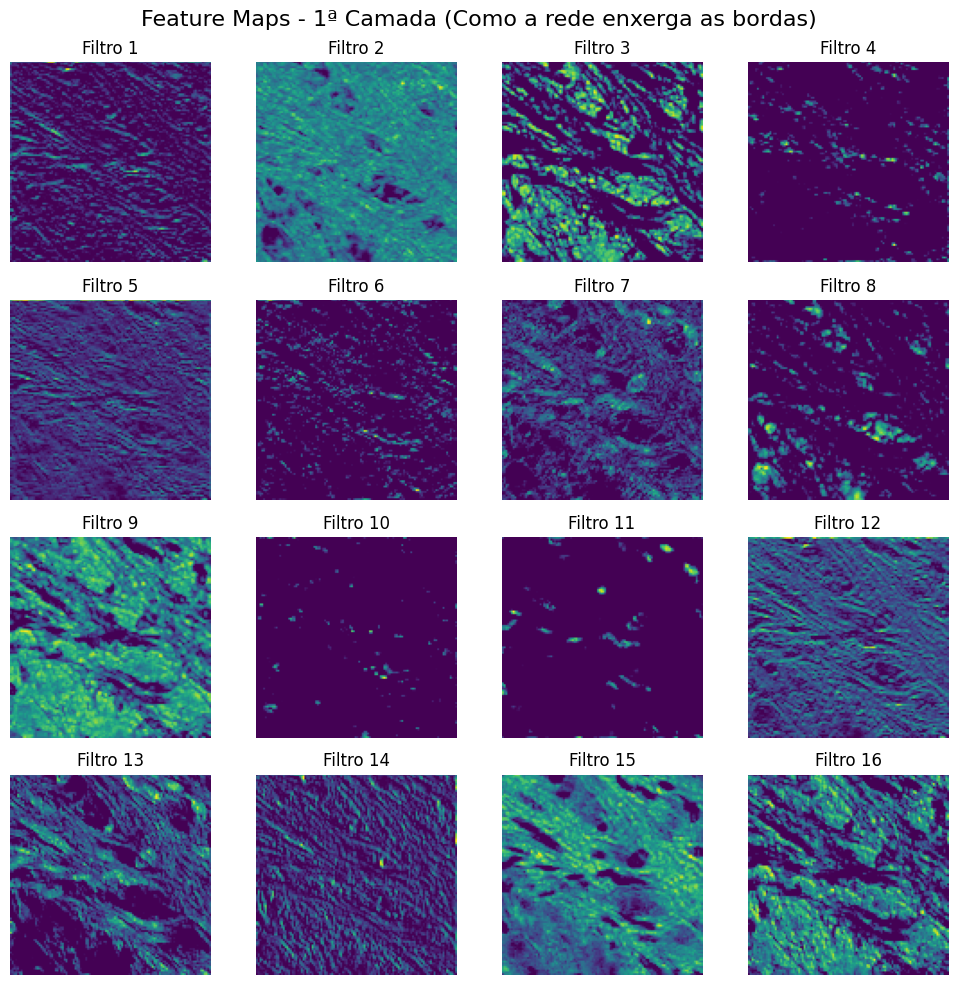

In [3]:
imagens_val, rotulos_val = next(iter(val_loader))
img_teste = imagens_val[0].unsqueeze(0).to(device) 

with torch.no_grad():
    # Passa a imagem apenas pelo primeiro bloco (Conv2d -> BatchNorm -> ReLU -> MaxPool)
    # Na nossa classe, isso corresponde aos 4 primeiros elementos do nn.Sequential 'features'
    ativacoes = modelo.features[:4](img_teste)

ativacoes = ativacoes.squeeze(0).cpu().numpy()

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("Feature Maps - 1ª Camada (Como a rede enxerga as bordas)", fontsize=16)

for i, ax in enumerate(axes.flat):
    ax.imshow(ativacoes[i], cmap='viridis')
    ax.axis('off')
    ax.set_title(f'Filtro {i+1}')

plt.tight_layout()
plt.savefig("feature_maps_relatorio.png", dpi=300)
plt.show()

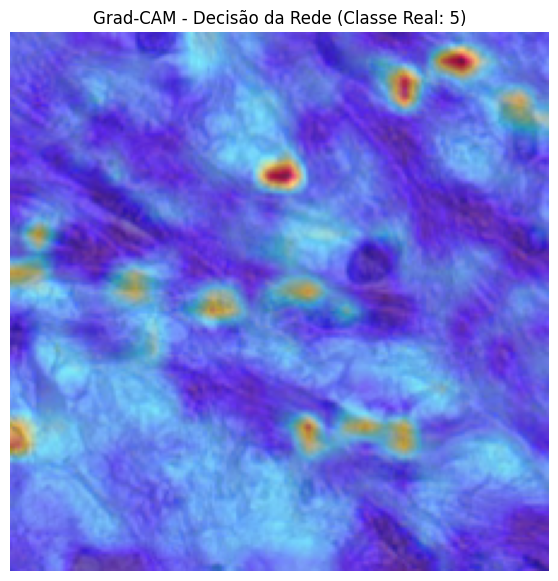

In [4]:
# Focamos na última camada convolucional antes do Pooling/Classificador
camada_alvo = [modelo.features[-1]]
cam = GradCAM(model=modelo, target_layers=camada_alvo)

# Gera a máscara térmica
mascara = cam(input_tensor=img_teste, targets=None)[0, :]

# Converte o tensor normalizado de volta para uma imagem colorida visível
img_rgb = img_teste.squeeze().cpu().numpy().transpose(1, 2, 0)
mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
img_rgb = np.clip(std * img_rgb + mean, 0, 1)

visualizacao = show_cam_on_image(img_rgb, mascara, use_rgb=True)

plt.figure(figsize=(7, 7))
plt.imshow(visualizacao)
plt.title(f"Grad-CAM - Decisão da Rede (Classe Real: {rotulos_val[0].item()})")
plt.axis('off')
plt.savefig("grad_cam_relatorio.png", dpi=300)
plt.show()

--- Iniciando Cálculo do Bônus: Integrated Gradients ---


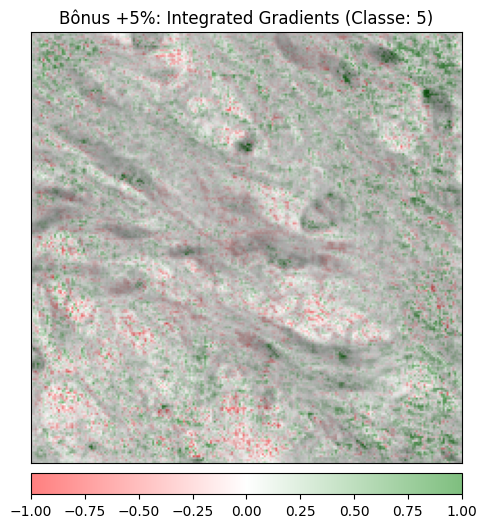

✅ Bônus gerado e salvo como 'integrated_gradients_bonus.png'!


In [5]:
from captum.attr import IntegratedGradients
from captum.attr import visualization as viz
import numpy as np
import matplotlib.pyplot as plt

print("--- Iniciando Cálculo do Bônus: Integrated Gradients ---")

# 1. Preparação: O Captum exige que o tensor de entrada rastreie gradientes
# Mesmo estando em modo de avaliação (.eval()), precisamos disso para calcular a atribuição
img_teste.requires_grad_()

# 2. Instanciando o método Integrated Gradients com o nosso modelo
ig = IntegratedGradients(modelo)

# 3. Calculando as atribuições (o que cada pixel contribuiu para a predição da classe)
# target=rotulo_teste garante que estamos explicando a classe real da imagem
atribuicoes, delta = ig.attribute(img_teste, target=rotulos_val[0].item(), return_convergence_delta=True)

# 4. Tratamento dos tensores para visualização gráfica
# Movemos para a CPU, transformamos em NumPy e ajeitamos os canais (C, H, W) para (H, W, C)
atribuicoes_np = atribuicoes.squeeze().cpu().detach().numpy().transpose(1, 2, 0)

# Reutilizando a imagem original colorida (img_rgb) que preparamos no código do Grad-CAM
# Caso ela não esteja no escopo, recriamos aqui rapidamente:
img_rgb_original = img_teste.squeeze().cpu().detach().numpy().transpose(1, 2, 0)
mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
img_rgb_original = np.clip(std * img_rgb_original + mean, 0, 1)

# 5. Visualização Profissional com Captum
fig, eixo = viz.visualize_image_attr(
    attr=atribuicoes_np,
    original_image=img_rgb_original,
    method="blended_heat_map", # Sobrepõe os gradientes na imagem original
    sign="all", # Mostra tanto contribuições positivas (verde) quanto negativas (vermelho)
    show_colorbar=True,
    title=f"Bônus +5%: Integrated Gradients (Classe: {rotulos_val[0].item()})"
)

# A função do Captum já retorna a figura, então apenas salvamos para o relatório PDF
fig.savefig("integrated_gradients_bonus.png", dpi=300)
print("✅ Bônus gerado e salvo como 'integrated_gradients_bonus.png'!")